(284807, 31)
Total missing values in the dataset: 0
Min 'Amount': 0.0
Max 'Amount': 25691.16
Lower bound for 'Amount': -101.7475
Upper bound for 'Amount': 184.5125
Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
Original class distribution in y_train:
Class
0    227451
1       394
Name: count, dtype: int64


/opt/anaconda3/envs/ml_tool/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



Class distribution after applying SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


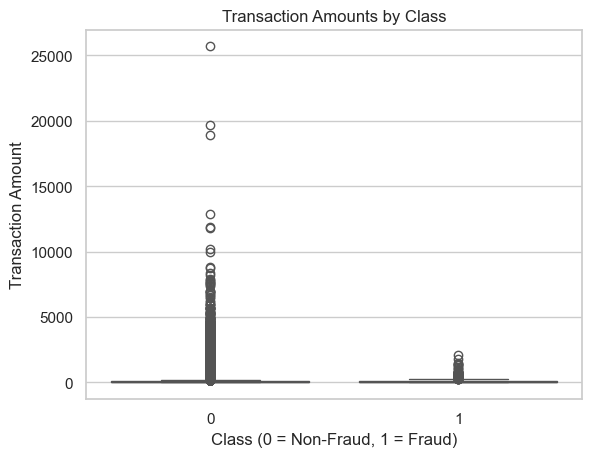

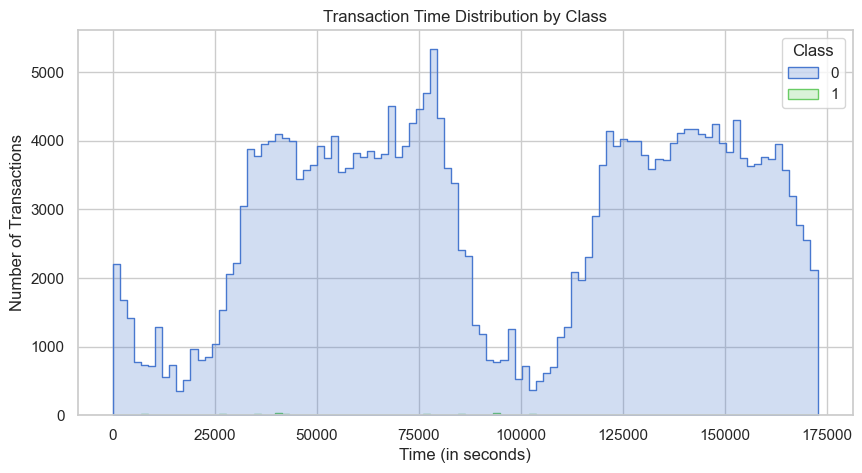

/var/folders/6x/xx3v5nsj2f9_pw57wkxsz5k80000gn/T/ipykernel_34307/1549496904.py:107: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df[df['Class'] == 0], x=feature, label='Not Fraud', fill=True, alpha=0.5)
/var/folders/6x/xx3v5nsj2f9_pw57wkxsz5k80000gn/T/ipykernel_34307/1549496904.py:108: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df[df['Class'] == 1], x=feature, label='Fraud', fill=True, alpha=0.5)
/var/folders/6x/xx3v5nsj2f9_pw57wkxsz5k80000gn/T/ipykernel_34307/1549496904.py:111: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


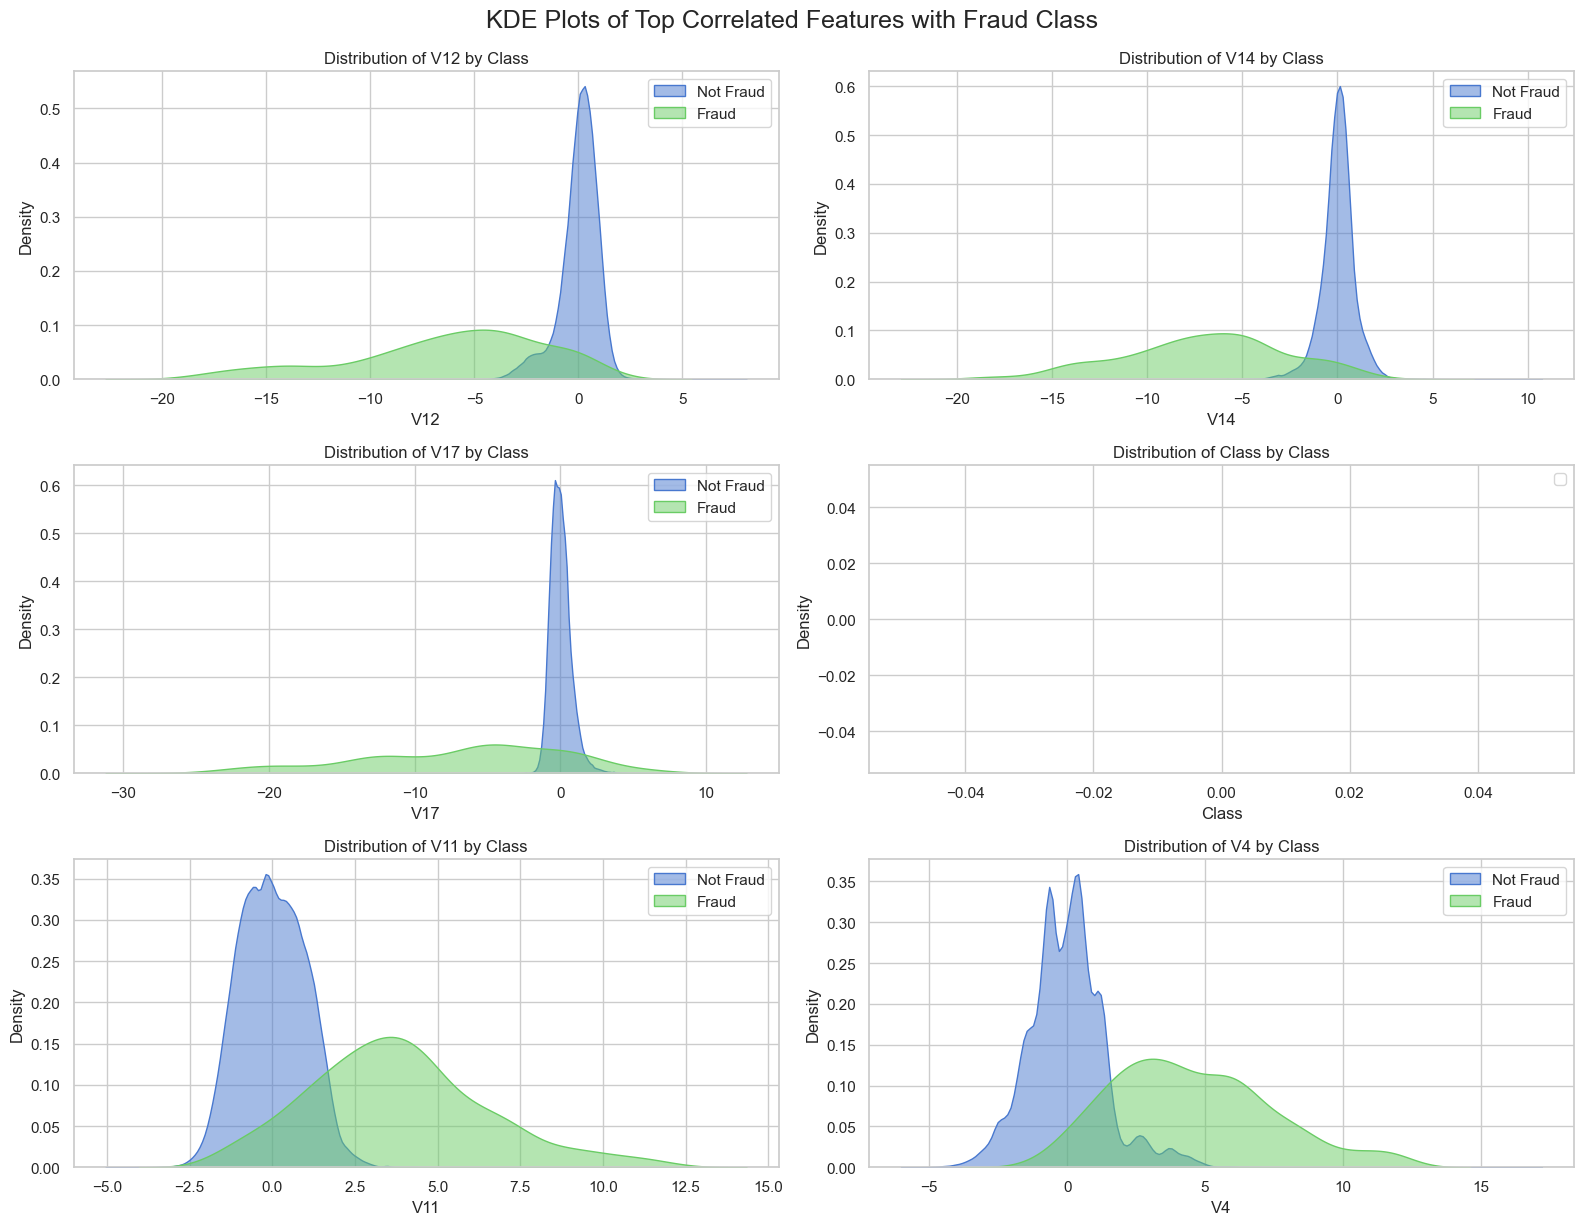

Confusion Matrix at threshold 0.3: [[56849    15]
 [   30    68]]

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.69      0.75        98

    accuracy                           1.00     56962
   macro avg       0.91      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962


Accuracy Score: 0.9992099996488887

Feature Coefficients (Influence on Fraud):
    Feature  Coefficient
22     V22     0.779169
21     V21     0.712414
7       V7     0.481869
4       V4     0.447295
1       V1     0.410485
20     V20     0.353349
12     V12     0.309367
18     V18     0.203060
26     V26     0.161569
28     V28     0.101211
23     V23     0.029026
24     V24     0.023682
0     Time    -0.000042
29  Amount    -0.003965
19     V19    -0.008108
6       V6    -0.014155
5       V5    -0.018611
27     V27    -0.207775
8       V8    -0.311738
2       V2    -0.35094

/opt/anaconda3/envs/ml_tool/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
#Install missing packages inside your Anaconda environment if needed
!pip install imbalanced-learn

#Importing the libraries
#For data manipulation
import pandas as pd
#For numerical operations
import numpy as np
#To visualise by means of plotting
import matplotlib.pyplot as plt
#For better statistical plots
import seaborn as sns     

#Instantiating machine Learning and evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

#Loading dataset that we are referencing
df = pd.read_csv('creditcard.csv')

# ✅ Preview
print(df.shape)
df.head()

#Starting data preprocessing to balance the data and reduce noise
#Check if any missing values exist
#Counting the true missing values in the dataset(not neutral values as per PCA)
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")


#Using IQR method to identify outliers in 'Amount'
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

#Defining the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Min 'Amount': {df['Amount'].min()}")
print(f"Max 'Amount': {df['Amount'].max()}")
print(f"Lower bound for 'Amount': {lower_bound}")
print(f"Upper bound for 'Amount': {upper_bound}")

#For this exercise we will keep the outliers considering the fraud itself is a highlight of an 'abnormality' 
#Now we mining the data to discover knowledge
#breakdown of how many positives and negatives there are in the dataframe
class_counts = df['Class'].value_counts()
print("Class Distribution:")
print(class_counts)

#Percentage breakdown
percentages = df['Class'].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
print(percentages)

#Now I apply SMOTE which is a technique used to help the model learn better so its not overfitting
#Separating the features and target
X = df.drop('Class', axis=1)  # Features (V1 to V28 + Amount + Time)
y = df['Class']               # Target (0 = non-fraud, 1 = fraud)

#Splitting data (to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#Print original class distribution
print("Original class distribution in y_train:")
print(y_train.value_counts())

#Apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#Print new class distribution
print("\nClass distribution after applying SMOTE:")
print(y_train_smote.value_counts())

#Determing how many transactions are fraud vs non-fraud by normalising the data and visualising using a box plot
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amounts by Class")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

#Determining the trend of the transactions over time, colored by class
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Time', hue='Class', bins=100, kde=False, element="step")
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (in seconds)")
plt.ylabel("Number of Transactions")
plt.show()

#now we want to show the correlation of each variable with 'Class'
correlations = df.corr()['Class'].sort_values(ascending=False)
# Select top 3 positively and top 3 negatively correlated features
top_pos_corr = correlations.tail(3).index
top_neg_corr = correlations.head(3).index
top_features_kde = top_pos_corr.tolist() + top_neg_corr.tolist()

#Deploying KDE Plots to show whether a feature is positively or negatively skewed
plt.figure(figsize=(16, 12))

for i, feature in enumerate(top_features_kde):
    plt.subplot(3, 2, i + 1)
    sns.kdeplot(data=df[df['Class'] == 0], x=feature, label='Not Fraud', fill=True, alpha=0.5)
    sns.kdeplot(data=df[df['Class'] == 1], x=feature, label='Fraud', fill=True, alpha=0.5)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.legend()

plt.tight_layout()
plt.suptitle('KDE Plots of Top Correlated Features with Fraud Class', fontsize=18, y=1.02)
plt.show()

#Statistical interpretation using losgistic regression model to interpret 
#Training the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

#Predicting probabilities instead of hard classes so to catch more fraud cases
y_prob = log_reg_model.predict_proba(X_test)[:, 1]  # get probabilities for class 1

#In order to increase the recall rate, I apply a lower threshold because FN cost>FP cost
threshold = 0.3
y_pred_threshold = (y_prob >= threshold).astype(int)


#Evaluating the performance of the model
print("Confusion Matrix at threshold 0.3:", confusion_matrix(y_test, y_pred_threshold))
print("\nClassification Report:", classification_report(y_test, y_pred_threshold))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_threshold))

#Here we are checking the feature importance (coefficients)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg_model.coef_[0]
})
coefficients.sort_values(by='Coefficient', ascending=False, inplace=True)
print("\nFeature Coefficients (Influence on Fraud):\n", coefficients)
